In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path_soap = '/content/drive/MyDrive/pinns/Laminado1D'
import sys
sys.path.append(path_soap)

In [3]:
import os
from tqdm import trange
import pickle

import torch
import torch.nn as nn
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from optimizer.soap import SOAP

#### Check cuda availability

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
Tesla T4


In [5]:
DEVICE = torch.device('cuda')

# Hyperparameters

#### Random numbers

In [6]:
SEED = 1234
seeds = [7, 13, 29, 42, 73, 91, 123, 256, 512, 1024]

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.determinist = True
torch.backends.cudnn.benchmark = False

### NN configuration

In [7]:
LAYERS = [1,100,100,100,1]
EPOCHS = 100000  # 1500 # 1000

LOG_STEP = 5
date = '2025_11_23'
train_flag = False

### Problem parameters

In [8]:
y_I = 0.2 # 0.3,0.2

VF_mat1 = y_I
VF_mat2 = 1 - VF_mat1

C_mat1 = 45 # 45, 3.4
C_mat2 = 12 # 12, 85

PARAM = {'VF_mat1':VF_mat1, 'VF_mat2':VF_mat2, 'C_mat1':C_mat1, 'C_mat2':C_mat2}

### Build Dataset

#### Train data

In [9]:
N_COLLOCATION = 500 #100
N_UNIQUENESS  = 1000
N_BOUNDARY = 1

# Interface
y_interface = np.array([[y_I]])

# Uniqueness
y_uniqueness1 = np.linspace(0, y_I, N_UNIQUENESS)[:,None]
y_uniqueness2 = np.linspace(y_I, 1, N_UNIQUENESS)[:,None]

#### Calculation of the effective properties

In [10]:
N_POINTS = 1000

y_points1 = np.linspace(0,    y_I, N_POINTS )[:,None]
y_points2 = np.linspace(y_I,  1,   N_POINTS )[:,None]

y_points_exact = np.concatenate((y_points1,y_points2))

# PINN Configuration

In [11]:
class FCN(nn.Module):

    def __init__(self, layers, device, activation = nn.Tanh()):

        super().__init__()

        self.device = device
        self.layers = layers
        self.activation = activation

        # Initialize the neural network as a list
        #Poner nn.Linear(self.layers[i], self.layers[i+1], bias=False)
        self.linear = nn.ModuleList([nn.Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers)-1)])

        # Xavier Initialization
        for i in range(len(self.layers)-1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain = 1.0)

            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, X):

        if torch.is_tensor(X) != True:
            X = torch.from_numpy(X)

        a = X.float()

        for i in range(len(self.layers)-2):
            z = self.linear[i](a)
            a = self.activation(z)

        NN_pred = self.linear[-1](a)

        return NN_pred

In [12]:
class PINNSampler:
    def __init__(self, a, b, n_points, device):
        self.a = a
        self.b = b
        self.n_points = n_points
        self.device = device

    def sample(self):
        #muestreo uniforme en [a,b]
        x = self.a + torch.rand(self.n_points, 1, device=self.device, requires_grad=True) * (self.b - self.a)
        return x

In [13]:
class PINN(nn.Module):

    def __init__(self, y_interface, param, layers, device, prob_name):

        super().__init__()

        self.device = device
        self.vf = y_interface[0,0]
        print(f"yI = {self.vf}")
        self.prob_name = prob_name
        #colocation points
        self.sampler1 = PINNSampler(0, self.vf, N_COLLOCATION, device)
        self.sampler2 = PINNSampler(self.vf, 1, N_COLLOCATION, device)

        #boundary points
        self.y_pc0 = torch.tensor([0.0], requires_grad=False).float().to(self.device)
        self.y_pc1 = torch.tensor([1.0], requires_grad=False).float().to(self.device)

        #Interface points
        self.y_inter = torch.tensor(y_interface, requires_grad= True).float().to(self.device)
        self.null_inter = torch.zeros(self.y_inter.shape, dtype = torch.float32, requires_grad=False).to(self.device)

        #PDE parameters
        self.VF_mat1 = param['VF_mat1']
        self.VF_mat2 = param['VF_mat2']
        self.C_mat1  = param['C_mat1']
        self.C_mat2  = param['C_mat2']

        ##NN
        self.layers = layers
        self.activation = nn.Tanh()
        self.best = np.inf

        #Networks initialization
        self.fcn_mat1 = FCN(self.layers,self.device, activation=self.activation)
        self.fcn_mat1.to(self.device)
        self.fcn_mat2 = FCN(self.layers,self.device, activation=self.activation)
        self.fcn_mat2.to(self.device)

        ### Parameters
        # Get the parameters as separate lists
        fcp_mat1_param = list(self.fcn_mat1.parameters())
        fcp_mat2_param = list(self.fcn_mat2.parameters())
        params = fcp_mat1_param + fcp_mat2_param

        self.optimizer  = SOAP(params, lr=0.001)
        self.scheduler  = torch.optim.lr_scheduler.ExponentialLR(self.optimizer, gamma=0.9)
        self.weights = [torch.tensor(1.0, requires_grad=False), torch.tensor(1.0, requires_grad=False),
                        torch.tensor(1.0, requires_grad=False)]
        self.w_update_freq = 100

        ## loss function
        self.loss_fn = nn.MSELoss(reduction ='mean')

        # Loggers
        self.loss_log             = []
        self.loss_collocation_log = []
        self.loss_interface_log   = []
        self.loss_bc_log          = []

        self.it = 0
        self.best_iter = 0
        self.log_every = 1
        self.pbar = None

    def forward_mat1(self, points):
        Chi_mat1_pred = self.fcn_mat1(points)
        return Chi_mat1_pred

    def forward_mat2(self, points):
        Chi_mat2_pred = self.fcn_mat2(points)
        return Chi_mat2_pred

    def Loss_bc(self):
        #Predicted
        Chi_pred_mat1 = self.forward_mat1(self.y_pc0)
        Chi_pred_mat2 = self.forward_mat2(self.y_pc1)
        # Compute losses
        loss_bc = 0.5*((Chi_pred_mat1)**2 + (Chi_pred_mat2)**2)
        return loss_bc

    def Loss_Collocation(self):

        #Predicted
        Chi_mat1_pred = self.forward_mat1(self.y_mat1)
        Chi_mat2_pred = self.forward_mat2(self.y_mat2)

        Chi_mat1_pred_y  = torch.autograd.grad(Chi_mat1_pred, self.y_mat1, grad_outputs=torch.ones_like(Chi_mat1_pred), create_graph=True)[0]
        Chi_mat1_pred_yy = torch.autograd.grad(Chi_mat1_pred_y, self.y_mat1, grad_outputs=torch.ones_like(Chi_mat1_pred_y), create_graph=True)[0]

        Chi_mat2_pred_y  = torch.autograd.grad( Chi_mat2_pred, self.y_mat2, grad_outputs=torch.ones_like(Chi_mat2_pred), create_graph=True)[0]
        Chi_mat2_pred_yy = torch.autograd.grad(Chi_mat2_pred_y, self.y_mat2, grad_outputs=torch.ones_like(Chi_mat2_pred_y), create_graph=True)[0]

        equ1 = self.C_mat1*Chi_mat1_pred_yy
        equ2 = self.C_mat2*Chi_mat2_pred_yy

        self.null_mat1 = torch.zeros(self.y_mat1.shape, dtype = torch.float32, requires_grad = False).to(self.device)
        self.null_mat2 = torch.zeros(self.y_mat2.shape, dtype = torch.float32, requires_grad = False).to(self.device)

        loss_collocation = self.loss_fn(equ1, self.null_mat1) + self.loss_fn(equ2, self.null_mat2)

        peso = 0.0
        loss_reg = peso*(self.loss_fn(Chi_mat1_pred, self.null_mat1) + self.loss_fn(Chi_mat2_pred, self.null_mat2))

        return loss_collocation + loss_reg

    def Loss_Interface(self):

        #Predicted
        Chi_mat1_pred = self.forward_mat1(self.y_inter)
        Chi_mat2_pred = self.forward_mat2(self.y_inter)

        Chi_mat1_pred_y = torch.autograd.grad(Chi_mat1_pred, self.y_inter, grad_outputs=torch.ones_like(Chi_mat1_pred), create_graph=True)[0]
        Chi_mat2_pred_y = torch.autograd.grad(Chi_mat2_pred, self.y_inter, grad_outputs=torch.ones_like(Chi_mat2_pred), create_graph=True)[0]

        equ1 = self.C_mat1*Chi_mat1_pred_y + self.C_mat1
        equ2 = self.C_mat2*Chi_mat2_pred_y + self.C_mat2

        loss_interface1 = self.loss_fn(Chi_mat1_pred - Chi_mat2_pred, self.null_inter)
        loss_interface2 = self.loss_fn(equ1 - equ2, self.null_inter)

        loss_interface = loss_interface1 + loss_interface2
        return loss_interface

    def loss(self):
        loss_collocation  = self.Loss_Collocation( )
        loss_interface    = self.Loss_Interface( )
        loss_bc           = self.Loss_bc()
        return loss_collocation, loss_interface, loss_bc

    def compute_gradients(self, loss_collocation, loss_interface, loss_bc):
        params = list(self.fcn_mat1.parameters()) + list(self.fcn_mat2.parameters())
        #collocations
        grads_co = torch.autograd.grad(loss_collocation, params, allow_unused=True)
        #interface
        grads_it = torch.autograd.grad(loss_interface, params)
        #uniqueness
        grads_bc = torch.autograd.grad(loss_bc, params)
        return grads_co, grads_it, grads_bc

    def compute_weights(self):
        alpha = 0.9
        eps = 1e-18
        l_residual, l_interface, l_bc = self.loss()
        grads_co, grads_it, grads_bc = self.compute_gradients(l_residual, l_interface, l_bc)

        n_co = torch.linalg.norm(torch.cat([g.view(-1) for g in grads_co if g is not None]))
        n_it = torch.linalg.norm(torch.cat([g.view(-1) for g in grads_it]))
        n_bc = torch.linalg.norm(torch.cat([g.view(-1) for g in grads_bc]))
        del grads_co, grads_it, grads_bc

        total_norm = n_co + n_it + n_bc
        self.weights[0] = alpha * self.weights[0] + (1-alpha) * (total_norm / (n_co + eps))
        self.weights[1] = alpha * self.weights[1] + (1-alpha) * (total_norm / (n_it + eps))
        self.weights[2] = alpha * self.weights[2] + (1-alpha) * (total_norm / (n_bc + eps))

    def Log(self, loss_total, loss_collocation, loss_interface, loss_bc, pbar, it, log_every):
        # Store losses
        self.loss_log.append(loss_total.item())
        self.loss_collocation_log.append(loss_collocation.item())
        self.loss_interface_log.append(loss_interface.item())
        self.loss_bc_log.append(loss_bc.item())

        # Log information
        if it % log_every == 0:
           pbar.set_postfix({'Loss': loss_total.item(),
                            'Residual loss': loss_collocation.item(),
                            'Interface loss': loss_interface.item(),
                            'BC loss': loss_bc.item()})

    def train(self, epochs=10000, log_every=10):

        self.log_every = log_every
        self.pbar = trange(epochs)
        save_dir = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

        for it in self.pbar:

            self.it = it
            self.y_mat1 = self.sampler1.sample()
            self.y_mat2 = self.sampler2.sample()

            if it % self.w_update_freq == 0:
               self.compute_weights()
            w1, w2, w3 = self.weights[0].detach().item(), self.weights[1].detach().item(), self.weights[2].detach().item()

            self.optimizer.zero_grad()
            l_residual, l_interface, l_bc = self.loss()
            loss_total = w1*l_residual + w2*l_interface + w3*l_bc
            loss_total.backward()
            self.optimizer.step()

            if it % 1000 == 0:   #probar 500
                self.scheduler.step()
                self.Log(loss_total, l_residual, l_interface, l_bc, self.pbar, self.it, self.log_every)

            if loss_total.item() < self.best:

                file_name = f"model_laminated1d_pinns_date:{date}_vf:{self.prob_name}.pth"
                file_path = os.path.join(save_dir, file_name)
                torch.save(self.state_dict(), file_path)
                self.best = loss_total.item()
                self.best_iter = it

        data = {'total_loss': self.loss_log,
                'collocation_loss': self.loss_collocation_log,
                'interface_loss': self.loss_interface_log,
                'bc_loss': self.loss_bc_log}
        df = pd.DataFrame(data)
        path_to_save = os.path.join(save_dir, f'losses_{date}_{self.vf}.csv')
        df.to_csv(path_to_save, index=False)

        return self.best_iter, data

    def Effective_Properties(self, points1, points2, verbose = True):

        y_mat1 = torch.tensor(points1, requires_grad=True).float().to(DEVICE)
        y_mat2 = torch.tensor(points2, requires_grad=True).float().to(DEVICE)

        Chi_mat1_pred = self.forward_mat1(y_mat1)
        Chi_mat2_pred = self.forward_mat2(y_mat2)

        Chi_mat1_pred_y = torch.autograd.grad(Chi_mat1_pred, y_mat1, grad_outputs=torch.ones_like(Chi_mat1_pred), create_graph=True)[0]
        Chi_mat2_pred_y = torch.autograd.grad(Chi_mat2_pred, y_mat2, grad_outputs=torch.ones_like(Chi_mat2_pred), create_graph=True)[0]

        Exp_mat1 = self.C_mat1 + self.C_mat1*Chi_mat1_pred_y
        Exp_mat2 = self.C_mat2 + self.C_mat2*Chi_mat2_pred_y

        # Via_1
        #Perform the integration using the trapezoidal rule
        integral_Exp1 = torch.trapezoid(Exp_mat1, y_mat1, dim=0)
        integral_Exp2 = torch.trapezoid(Exp_mat2, y_mat2, dim=0)
        #Sum the integrals
        C_eff = integral_Exp1 + integral_Exp2
        C_eff = C_eff.detach().cpu().numpy()

        Chi_pred = torch.concatenate((Chi_mat1_pred,Chi_mat2_pred))
        Chi_pred=Chi_pred.detach().cpu().numpy()

        return C_eff[0], Chi_pred

In [14]:
def calcular_mn(C1, C2, yI):
    m1 = -((C1 - C2) * (-1 + yI)) / (-C1 + C1 * yI - C2 * yI)
    m2 = -((-C1 + C2) * yI) / (C1 - C1 * yI + C2 * yI)
    n1 = 0
    n2 = -m2
    return m1, m2, n1, n2

def calcular_chi(C1, C2, yI, y1, y2):
    m1, m2, n1, n2 = calcular_mn(C1, C2, yI)
    chi1 = m1 * y1 + n1
    chi2 = m2 * y2 + n2
    return chi1, chi2

### TRAINING

In [15]:
if train_flag:
    volum_frac = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    volum_frac_str = [str(v) for v in volum_frac]

    N_dict     = {}
    N_analytic = {}
    points_y   = {}
    table_rows = []
    save_dir = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
    best_iter_dic = {}

    for vf, vf_str in zip(volum_frac, volum_frac_str):
        print(f"\n ---- For vf = {vf} ----")

        VF_mat1 = vf
        VF_mat2 = 1 - vf
        C_mat1 = 45
        C_mat2 = 12
        PARAM = {'VF_mat1':VF_mat1, 'VF_mat2':VF_mat2, 'C_mat1':C_mat1, 'C_mat2':C_mat2}

        #Interface
        y_interface = np.array([[vf]])

        #data for predictions
        N_POINTS = 1000
        y_points1 = np.linspace(0, vf, N_POINTS )[:,None]
        y_points2 = np.linspace(vf, 1, N_POINTS )[:,None]
        y1 = y_points1
        y2 = y_points2
        #predict
        y1_tensor = torch.tensor(y1, requires_grad=True).float().to(DEVICE)
        y2_tensor = torch.tensor(y2, requires_grad=True).float().to(DEVICE)

        #pinns trainning
        model = PINN(y_interface, param = PARAM, layers = LAYERS, device = DEVICE, prob_name = vf_str)
        model.to(DEVICE)
        bestIter, datos = model.train(epochs = EPOCHS, log_every=LOG_STEP)
        best_iter_dic[vf_str] = bestIter

        save_dir   = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
        file_name  = f"model_laminated1d_pinns_date:{date}_vf:{vf_str}.pth"
        file_path  = os.path.join(save_dir, file_name)
        model.load_state_dict(torch.load(file_path))
        model.to(DEVICE)
        model.eval()

        each_loss = {'total_loss': datos['total_loss'],
                     'collocation_loss': datos['collocation_loss'],
                     'interface_loss': datos['interface_loss'],
                     'bc_loss': datos['bc_loss']}

        each_loss1 = {'collocation_loss': datos['collocation_loss'],
                     'interface_loss': datos['interface_loss'],
                     'bc_loss': datos['bc_loss']}

        each_loss2 = {'total_loss': datos['total_loss']}

        df = pd.DataFrame(each_loss)
        df.to_csv(os.path.join(save_dir, f'table_losses_total_col_bc_interf{date}_{vf_str}.csv'), index=False)
        df1 = pd.DataFrame(each_loss1)
        df2 = pd.DataFrame(each_loss2)

        ax1 = df1.plot(figsize=(8,6))
        #plt.ylim(0, 1)
        plt.xlabel('Epoch')
        plt.yscale('log', base=10)
        plt.ylabel('Losses')
        out_name = os.path.join(save_dir, f'losses_col_bc_interf_{date}_{vf_str}.png')
        plt.savefig(out_name)
        plt.grid(True)
        ax1.legend(loc='upper right', fontsize=12)
        plt.show()

        ax2 = df2.plot(figsize=(8,6))
        #plt.ylim(0, 1)
        plt.xlabel('Epoch')
        plt.yscale('log', base=10)
        plt.ylabel('Total Loss')
        out_name = os.path.join(save_dir, f'losses_total_loss_{date}_{vf_str}.png')
        plt.savefig(out_name)
        plt.grid(True)
        ax2.legend(loc='upper right', fontsize=12)
        plt.show()

    with open(os.path.join(save_dir, "best_iters.pkl"), "wb") as f:
        pickle.dump(best_iter_dic, f)

CARGA LOS MEJORES MODELOS PARA CADA V1

In [16]:
date = '2025_11_23'
models = [f'model_laminated1d_pinns_date:{date}_vf:0.1.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.15.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.2.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.25.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.3.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.35.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.4.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.45.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.5.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.55.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.6.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.65.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.7.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.75.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.8.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.85.pth',
          f'model_laminated1d_pinns_date:{date}_vf:0.9.pth',  f'model_laminated1d_pinns_date:{date}_vf:0.95.pth']


vol_fractions = ['0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4', '0.45', '0.5', '0.55',  '0.6', '0.65', '0.7', '0.75', '0.8', '0.85', '0.9', '0.95']
volum_frac    = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
save_path = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"


N_pinns  = {}
N_analy  = {}
points_y = {}
table_rows = []

for vf, vf_str, model_name in zip(volum_frac, vol_fractions, models):
    file_path = os.path.join(save_path, model_name)
    model = PINN(y_interface, param = PARAM, layers = LAYERS, device = DEVICE, prob_name = vf)
    model.load_state_dict(torch.load(file_path))
    model.to(DEVICE)
    model.eval()

    VF_mat1 = vf
    VF_mat2 = 1 - vf
    C_mat1 = 45
    C_mat2 = 12
    PARAM = {'VF_mat1':VF_mat1, 'VF_mat2':VF_mat2, 'C_mat1':C_mat1, 'C_mat2':C_mat2}

    #Interface
    y_interface = np.array([[vf]])

    #data for predictions of effective properties
    N_POINTS = 1000
    y_points1 = np.linspace(0, vf, N_POINTS )[:,None]
    y_points2 = np.linspace(vf, 1, N_POINTS )[:,None]
    y1 = y_points1
    y2 = y_points2
    #predict
    y1_tensor = torch.tensor(y1, requires_grad=True).float().to(DEVICE)
    y2_tensor = torch.tensor(y2, requires_grad=True).float().to(DEVICE)

    #propiedades efectivas
    C_eff_pred, Chi_pred= model.Effective_Properties(y_points1, y_points2)
    C_eff_exact = C_mat1*C_mat2/(VF_mat1*C_mat2 + VF_mat2*C_mat1)

    #data for predictions of local displacements
    N_POINTS = 500
    y_points1 = np.linspace(0, vf, N_POINTS )[:,None]
    y_points2 = np.linspace(vf, 1, N_POINTS )[:,None]
    y1 = y_points1
    y2 = y_points2
    #predict
    y1_tensor = torch.tensor(y1, requires_grad=True).float().to(DEVICE)
    y2_tensor = torch.tensor(y2, requires_grad=True).float().to(DEVICE)

    #estimated
    N_mat1 = model.forward_mat1(y1_tensor)
    N_mat1 = N_mat1.detach().cpu().numpy()
    N_mat2 = model.forward_mat2(y2_tensor)
    N_mat2 = N_mat2.detach().cpu().numpy()
    y = np.concatenate([y1.flatten(), y2.flatten()])
    N_mat = np.concatenate([N_mat1.flatten(), N_mat2.flatten()])
    N_pinns[vf_str] = N_mat
    points_y[vf_str] = y

    #analytic
    n_points = 500
    c1, c2 = C_mat1, C_mat2
    y1 = np.linspace(0, vf, n_points)
    y2 = np.linspace(vf, 1, n_points)
    N1, N2 = calcular_chi(c1, c2, vf, y1, y2)
    N = np.concatenate([N1, N2])
    y = np.concatenate([y1, y2])
    N_analy[vf_str] = N

    table_rows.append({ 'vf': vf,
                        'C_eff_pred':  C_eff_pred,
                        'C_eff_exact': C_eff_exact,
                        'relative_error': (abs(C_eff_pred - C_eff_exact)/C_eff_exact)*100})

yI = 0.2


0it [00:00, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


yI = 0.1


0it [00:00, ?it/s]


yI = 0.15


...

0it [00:00, ?it/s]


yI = 0.85


0it [00:00, ?it/s]


yI = 0.9


0it [00:00, ?it/s]


In [17]:
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
file_name =  f'datos_{date}.npz'
file_path = os.path.join(save_dir, file_name)
np.savez(file_path, data1=N_pinns, data2=points_y, data3=table_rows, data4=N_analy)

In [18]:
loaded     = np.load(file_path, allow_pickle=True)
N_pinn     = loaded['data1'].item()
points_y   = loaded['data2'].item()
table_rows = loaded['data3'].tolist()
N_analy    = loaded['data4'].item()

In [19]:
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2029311402.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(df_summary['vf'], df_summary['C_eff_pred'], 'o-', label=f'$\hat{{E}}^*$')


  vf  C_eff_pred  C_eff_exact relative_error
0.10   12.949641    12.949640      7.36e-06%
0.15   13.483148    13.483146      1.41e-05%
0.20   14.062500    14.062500      0.00e+00%
0.25   14.693878    14.693878      6.49e-06%
0.30   15.384604    15.384615      7.44e-05%
0.35   16.143499    16.143498      1.18e-05%
0.40   16.981133    16.981132      0.00e+00%
0.45   17.910440    17.910448      4.26e-05%
0.50   18.947361    18.947368      4.03e-05%
0.55   20.111732    20.111732      0.00e+00%
0.60   21.428577    21.428571      2.67e-05%
0.65   22.929935    22.929936      0.00e+00%
0.70   24.657539    24.657534      2.32e-05%
0.75   26.666683    26.666667      6.44e-05%
0.80   29.032257    29.032258      6.57e-06%
0.85   31.858389    31.858407      5.99e-05%
0.90   35.294147    35.294118      8.65e-05%
0.95   39.560387    39.560440      1.35e-04%


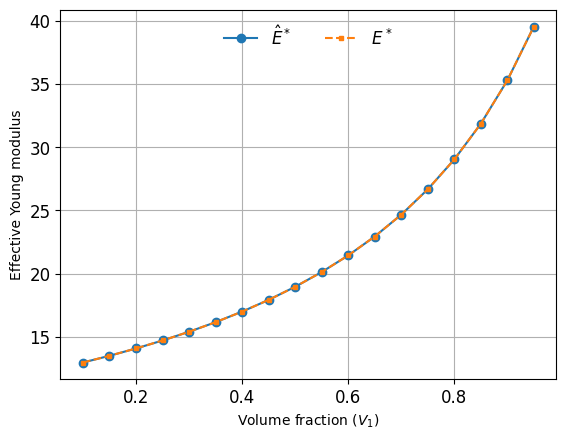

In [20]:
import pandas as pd
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

df_summary = pd.DataFrame(table_rows)
df_summary['relative_error'] = df_summary['relative_error'].map(lambda x: f"{x:.2e}%")
df_summary.to_csv(os.path.join(save_dir, f'table_{date}.csv'), index=False)
print(df_summary.to_string(index=False))

#coeficientes efectivos
plt.figure()
plt.plot(df_summary['vf'], df_summary['C_eff_pred'], 'o-', label=f'$\hat{{E}}^*$')
plt.plot(df_summary['vf'], df_summary['C_eff_exact'], 's--', label=f'${{E}}^*$', markersize=2.2)
plt.xlabel(r'Volume fraction $(V_1)$')
plt.ylabel('Effective Young modulus')
plt.legend(loc='upper center', ncol=4, frameon=False)
plt.grid(True)
outname = os.path.join(save_dir, f'Ceff vs vf_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()

DESPLAZAMIENTO LOCAL

In [21]:
'''
import matplotlib.cm as cm
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, 8))
coordenates0 = [(0.49, -0.06), (0.49, -0.15), (0.60, -0.2), (0.85, -0.25)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

i=0
for k, vf in enumerate([0.2, 0.4, 0.6, 0.8]):
    axes[0].plot(points_y[str(vf)], N_analy[str(vf)], linestyle='--', linewidth=2.5,
                 color=colors[i])
    axes[0].plot(points_y[str(vf)], N_pinns[str(vf)], linestyle='-', linewidth=1.5,
                 color=colors[i+1])
    axes[0].text(coordenates0[k][0], coordenates0[k][1], f'$V_1$={vf}')

    error = np.abs(N_pinns[str(vf)] - N_analy[str(vf)])
    axes[1].plot(points_y[str(vf)], error, linewidth=2, color=colors[i], label=f'$V_1$={vf}')
    i += 2

axes[0].set_xlabel('y')
axes[0].set_ylabel('Local problem solutions')
axes[0].grid(True)

axes[1].set_xlabel('y') # Corrected line
axes[1].ticklabel_format(style='sci', axis='y',
                         scilimits=(0,0))
axes[1].set_ylabel('Absolute Error')


axes[1].grid(True)

axes[0].legend([
        plt.Line2D([0], [0], color='gray', linestyle='-', linewidth=1.5),
        plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2),],
        ['PINNs (continuous)', 'Analytical (dashed)'],
        loc='upper center', bbox_to_anchor=(0.5, 1.15),
        ncol=2, frameon=False)

axes[1].legend(loc='upper left',
               ncol=1,
               frameon=False)

plt.tight_layout()
outname = os.path.join(save_dir, f'pseudo_disp_analytical_vs_pinns_for_various_vf_{date}.png')
plt.savefig(outname,  bbox_inches='tight')
plt.show()
'''

'\nimport matplotlib.cm as cm\nsave_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"\n\ncmap = plt.get_cmap(\'plasma\')\ncolors = cmap(np.linspace(0, 1, 8))\ncoordenates0 = [(0.49, -0.06), (0.49, -0.15), (0.60, -0.2), (0.85, -0.25)]\n\nfig, axes = plt.subplots(1, 2, figsize=(10, 4))\n\ni=0\nfor k, vf in enumerate([0.2, 0.4, 0.6, 0.8]):\n    axes[0].plot(points_y[str(vf)], N_analy[str(vf)], linestyle=\'--\', linewidth=2.5,\n                 color=colors[i])\n    axes[0].plot(points_y[str(vf)], N_pinns[str(vf)], linestyle=\'-\', linewidth=1.5,\n                 color=colors[i+1])\n    axes[0].text(coordenates0[k][0], coordenates0[k][1], f\'$V_1$={vf}\')\n\n    error = np.abs(N_pinns[str(vf)] - N_analy[str(vf)])\n    axes[1].plot(points_y[str(vf)], error, linewidth=2, color=colors[i], label=f\'$V_1$={vf}\')\n    i += 2\n\naxes[0].set_xlabel(\'y\')\naxes[0].set_ylabel(\'Local problem solutions\')\naxes[0].grid(True)\n\naxes[1].set_xlabel(\'y\') # Corrected line\naxes[1].ticklab

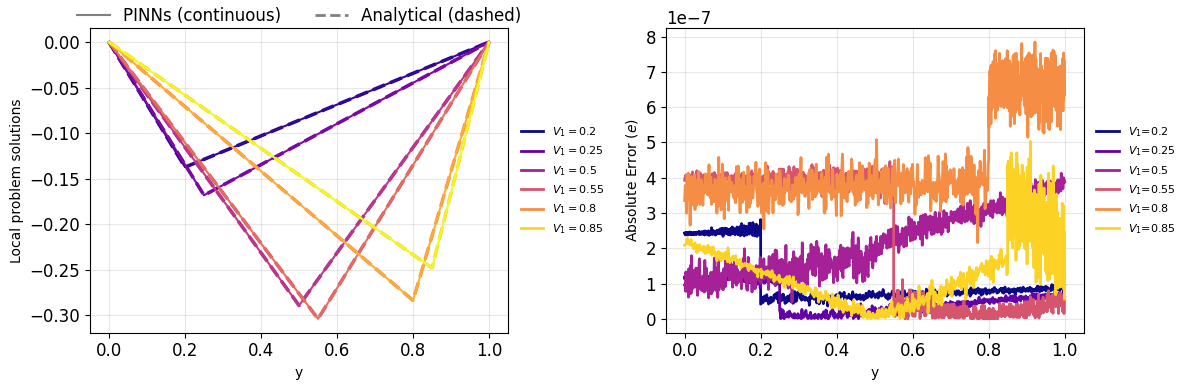

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

cmap = plt.get_cmap('plasma')
vfs = [0.2, 0.25, 0.5, 0.55, 0.8, 0.85]
colors = cmap(np.linspace(0, 1, 2*len(vfs)))
coordenates0 = [(0.49, -0.06), (0.49, -0.15), (0.60, -0.2), (0.85, -0.25)]


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

i=0
for vf in vfs:
    axes[0].plot(points_y[str(vf)], N_analy[str(vf)], linestyle='--', linewidth=2.5,
                 color=colors[i])
    axes[0].plot(points_y[str(vf)], N_pinns[str(vf)], linestyle='-', linewidth=1.5,
                 color=colors[i+1])

    error = np.abs(N_pinns[str(vf)] - N_analy[str(vf)])
    axes[1].plot(points_y[str(vf)], error, linewidth=2, color=colors[i], label=f'$V_1$={vf}')
    i += 2

axes[0].set_xlabel('y')
axes[0].set_ylabel('Local problem solutions')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('y') # Corrected line
axes[1].ticklabel_format(style='sci', axis='y',
                         scilimits=(0,0))
axes[1].set_ylabel(f'Absolute Error ($e$)')
axes[1].grid(True, alpha=0.3)

axes[1].legend(
    fontsize=8,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    borderaxespad=0,
    ncol=1
)

legend1 = axes[0].legend(
    [
        Line2D([0], [0], color='gray', linestyle='-', linewidth=1.5),
        Line2D([0], [0], color='gray', linestyle='--', linewidth=2),
    ],
    ['PINNs (continuous)', 'Analytical (dashed)'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

axes[0].add_artist(legend1)


handles = []
labels = []
i = 0
for c in vfs:
    color_for_entry = colors[i]
    handles.append(Line2D([0], [0], color=color_for_entry, linewidth=2))
    labels.append(f'$V_1={c}$')
    i += 2

axes[0].legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=False,
    fontsize=8,
    ncol=1
)

plt.tight_layout()
outname = os.path.join(save_dir, f'pseudo_disp_analytical_vs_pinns_for_various_vf_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()

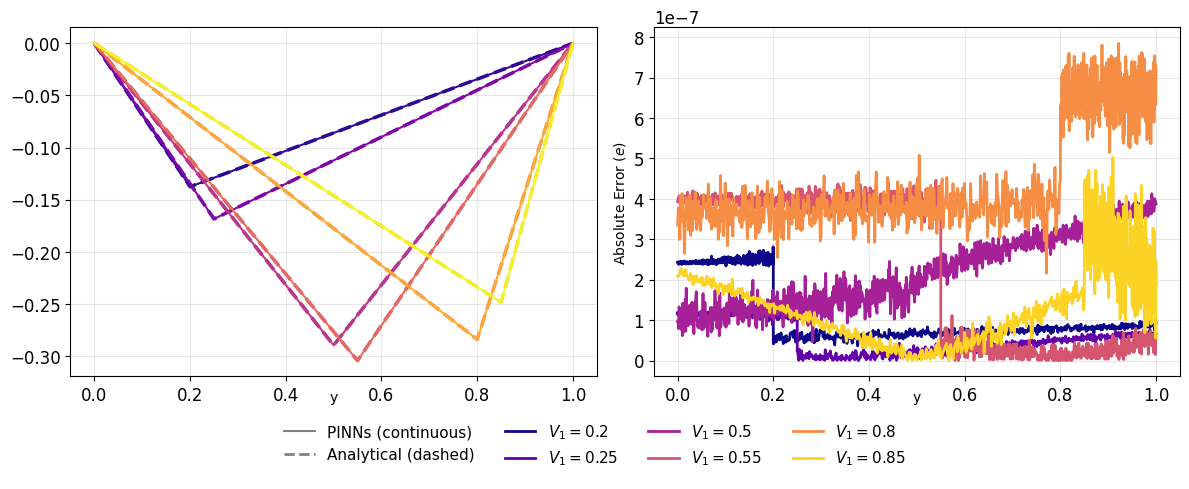

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

cmap = plt.get_cmap('plasma')
vfs = [0.2, 0.25, 0.5, 0.55, 0.8, 0.85]
colors = cmap(np.linspace(0, 1, 2*len(vfs)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

i = 0
for vf in vfs:
    axes[0].plot(points_y[str(vf)], N_analy[str(vf)], linestyle='--', linewidth=2.5,
                 color=colors[i])
    axes[0].plot(points_y[str(vf)], N_pinns[str(vf)], linestyle='-', linewidth=1.5,
                 color=colors[i+1])

    error = np.abs(N_pinns[str(vf)] - N_analy[str(vf)])
    axes[1].plot(points_y[str(vf)], error, linewidth=2, color=colors[i])

    i += 2

# Labels y grid
axes[0].set_xlabel('y', labelpad=-10)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('y', labelpad=-10)
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel('Absolute Error ($e$)')
axes[1].grid(True, alpha=0.3)

legend_handles = []
legend_handles.append(Line2D([0], [0], color='gray', linestyle='-',  linewidth=1.5, label='PINNs (continuous)'))
legend_handles.append(Line2D([0], [0], color='gray', linestyle='--', linewidth=2,   label='Analytical (dashed)'))

i = 0
for vf in vfs:
    legend_handles.append(
        Line2D([0], [0], color=colors[i], linewidth=2, label=f'$V_1={vf}$'))
    i += 2

#Leyenda global-
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    frameon=False,
    borderaxespad=1.0,
    fontsize=11
)

plt.tight_layout(rect=(0, 0.15, 1, 1))
outname = os.path.join(save_dir, f'pseudo_disp_analytical_vs_pinns_for_various_vf_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()

ERRORES DE LA APROXIMACION TWO-SCALE Y LA RECONTRUCCION A DOS ESCALA BASADA EN PINNS

In [23]:
train_epsilons_flag = False
if  train_epsilons_flag:
    from scipy.interpolate import interp1d
    from sklearn.metrics import mean_squared_error
    import pickle
    save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

    def solve_heterogeneous(x, eps, v1f, N, E1, E2, L=1):
        delta = x[1] - x[0]

        pos_period = x % eps
        E = np.where(pos_period <= v1f*eps, E1, E2)
        E_plus = np.zeros(N-1)

        for i in range(N-1):  #for each [x_i, x_{i+1}]
            k = int(x[i] / eps)
            disc1 = k * eps + v1f*eps     #material disc
            disc2 = (k + 1) * eps         #períodic disc

            if x[i] < disc1 < x[i+1]:
                disc = disc1
                E_b = E1
                E_a = E2
            elif x[i] < disc2 < x[i+1]:
                disc = disc2
                E_b = E2
                E_a = E1
            else:
                disc = None

            if disc is not None:
                v1 = disc - x[i]
                v2 = x[i+1] - disc
                E_plus[i] = (v1 + v2)*E_b*E_a / (v1*E_b + v2*E_a)
            else:
                E_plus[i] = E[i]

        A = np.zeros((N, N))
        b = np.zeros(N)

        A[0, 0] = 1
        b[0] = 0
        A[N-1, N-1] = 1
        b[N-1] = 1

        i = np.arange(1, N-1)
        A[i, i-1] = E_plus[i-1] / delta**2
        A[i, i] = -(E_plus[i-1] + E_plus[i]) / delta**2
        A[i, i+1] = E_plus[i] / delta**2

        u = np.linalg.solve(A, b)
        return u

    def two_scales(x, eps, y_grid, N):
        y = (x / eps) % 1.0
        N_interp = interp1d(y_grid, N, kind='linear',
                            bounds_error=False) #, fill_value="extrapolate")
        N = N_interp(y)
        u_eps = x + eps * N
        return u_eps

    def two_scales_v2(eps, y_grid, N):
        reps = int(round(1.0 / eps))
        y_core = y_grid[:-1]
        N_core = N[:-1]
        x_blocks = [(y_core + r) * eps for r in range(reps)]
        x = np.hstack(x_blocks)
        x = np.append(x, 1.0)

        N_rep = np.tile(N_core, reps)
        N_rep = np.append(N_rep, N[-1])
        return x + eps*N_rep, x

    u_homog = np.arange(0, 1.01, 0.001)
    u_homog = np.linspace(0,1, 10000)
    x_fd = u_homog
    N    = u_homog.size

    u_pinns      = {}
    u_twoscale   = {}
    u_heter      = {}
    rms_pinns    = {}
    rms_twoscale = {}
    rms_homog    = {}
    rms_pinns_vs_twoscale = {}
    df_metrics = {}

    vol_fractions = ['0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4', '0.45', '0.5',
                    '0.55',  '0.6', '0.65', '0.7', '0.75', '0.8', '0.85', '0.9', '0.95']
    epsilons = [0.5, 0.1, 0.01]
    fig, axes = plt.subplots(3, 1, figsize=(8, 16))

    for epsilon, ax in zip(epsilons, axes):
        print(f'\n ----------- epsilon = {epsilon} -----------\n')
        u_pinns[epsilon]      = {}
        u_twoscale[epsilon]   = {}
        u_heter[epsilon]      = {}
        rms_pinns[epsilon]    = {}
        rms_twoscale[epsilon] = {}
        rms_homog[epsilon]    = {}
        rms_pinns_vs_twoscale[epsilon] = {}
        for vf in vol_fractions:

            u_pinns[epsilon][vf]    = two_scales(x_fd, epsilon, points_y[vf], N_pinns[vf])
            u_twoscale[epsilon][vf] = two_scales(x_fd, epsilon, points_y[vf], N_analy[vf])
            u_heter[epsilon][vf]    = solve_heterogeneous(x_fd, epsilon, float(vf), N, PARAM['C_mat1'], PARAM['C_mat2'])

            rms_homog[epsilon][vf]             = np.sqrt(mean_squared_error(u_homog, u_heter[epsilon][vf]))
            rms_pinns[epsilon][vf]             = np.sqrt(mean_squared_error(u_pinns[epsilon][vf], u_heter[epsilon][vf]))
            rms_twoscale[epsilon][vf]          = np.sqrt(mean_squared_error(u_twoscale[epsilon][vf], u_heter[epsilon][vf]))
            #rms_pinns_vs_twoscale[epsilon][vf] = np.sqrt(mean_squared_error(u_pinns[epsilon][vf], u_twoscale[epsilon][vf]))

        v_fractions = list(rms_pinns[epsilon].keys())
        df_metrics[epsilon]  = pd.DataFrame({
                              'vf': v_fractions,
                              'RMS_PINNs':    [rms_pinns[epsilon][vf_key]    for vf_key in v_fractions],
                              'RMS_twoscale': [rms_twoscale[epsilon][vf_key] for vf_key in v_fractions],
                              'RMS_homog':    [rms_homog[epsilon][vf_key]    for vf_key in v_fractions],})


        path_to_save = os.path.join(save_dir, f"RMS_metrics_{epsilon}_{date}.csv")
        df_metrics[epsilon].to_csv(path_to_save, index=False)
        print(df_metrics[epsilon].to_string(index=False))

        ax.plot(df_metrics[epsilon]['vf'], df_metrics[epsilon]['RMS_PINNs'], label=f'$e^{{({epsilon})}}_{{pinns}}$', linewidth=1.5)
        ax.plot(df_metrics[epsilon]['vf'], df_metrics[epsilon]['RMS_twoscale'], label=f'$e^{{({epsilon})}}_{{TwoScale}}$', linestyle='--', linewidth=1.0)
        #plt.plot(df_metrics['vf'], df_metrics['RMS_homog'], label=f'$e^{(0)}}$')
        ax.set_xlabel(f"Volume fraction ($V_1$)")
        ax.set_ylabel(f"Absolute Error ($e$)")
        ax.legend(loc='upper center', ncol=2, frameon=False)
        ax.grid(True, alpha=0.3)

    fig.subplots_adjust(hspace=0.25)
    outname = os.path.join(save_dir, f'rms_vs_vf_{date}.png')
    plt.savefig(outname, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    outname = os.path.join(save_dir, 'desplazamientos.npz')
    np.savez(outname, d1=u_pinns, d2=u_twoscale, d3=u_heter)

    with open(os.path.join(save_dir, "df_metrics_all.pkl"), "wb") as f:
        pickle.dump(df_metrics, f)

In [24]:
with open(os.path.join(save_dir, "df_metrics_all.pkl"), "rb") as f:
     df_metrics = pickle.load(f)

data = np.load(os.path.join(save_dir, 'desplazamientos.npz'), allow_pickle=True)
u_pinns= data["d1"].item()
u_twoscale = data["d2"].item()
u_heter = data["d3"].item()

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal',

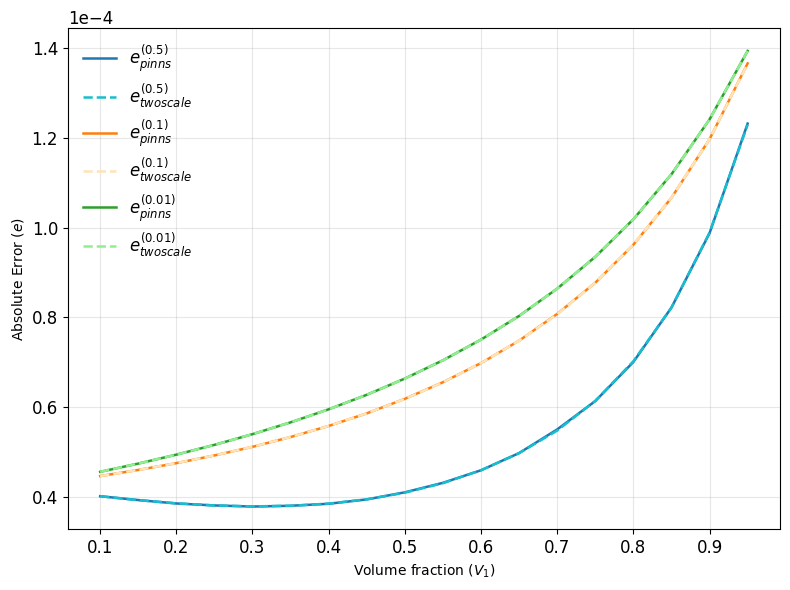

<Figure size 640x480 with 0 Axes>

In [30]:
fig, ax = plt.subplots(figsize=(8,6))
epsilons = [0.5, 0.1, 0.01]

colors = {
    0.5:   ('tab:blue', 'tab:cyan'),
    0.1:   ('tab:orange', 'moccasin'),
    0.01:  ('tab:green', 'lightgreen'),
}

for epsilon in epsilons:
    c_pinns, c_twoscale = colors[epsilon]

    # PINNs
    ax.plot(
        df_metrics[epsilon]['vf'].astype(float),
        df_metrics[epsilon]['RMS_PINNs'],
        label=f'$e^{{({epsilon})}}_{{pinns}}$',
        color=c_pinns,
        linewidth=1.8,
    )

    # twoscale
    ax.plot(
        df_metrics[epsilon]['vf'].astype(float),
        df_metrics[epsilon]['RMS_twoscale'],
        label=f'$e^{{({epsilon})}}_{{twoscale}}$',
        color=c_twoscale,
        linestyle='--',
        linewidth=1.8,
    )

ax.set_xlabel("Volume fraction ($V_1$)")
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_ylabel("Absolute Error ($e$)")
ax.grid(True, alpha=0.3)

ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.setp(ax.get_xticklabels())

# Leyenda vertical ordenada
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    loc='upper left',
    ncol=1,          # una columna
    frameon=False
)

outname = os.path.join(save_dir, f'rms_vs_vf_all_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

Muestra 4 graficas [0.2, 0.4, 0.6, 0.8] para cada  epsilon [0.5, 0.1, 0.01]

In [26]:
'''
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

epsilons = [0.5, 0.1, 0.01]
starting_point = [0.5, 0.5, 0.5]
for i, epsilon in enumerate(epsilons):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()
    print(f'\n graph for parameter epsilon:{epsilon}\n')
    for ax, vf in zip(axes, vol_fractions_for_visuali):

        ax.plot(x_fd, u_pinns[epsilon][vf],    'r', linewidth=1, label=f'$u^{{({epsilon})}}_{{pinns}}$')
        ax.plot(x_fd, u_twoscale[epsilon][vf], 'b', linewidth=1, label=f'$u^{{({epsilon})}}_{{TwoScale}}$')
        ax.plot(x_fd, u_heter[epsilon][vf],    'g', linewidth=1, label=f'$u^{{({epsilon})}}_{{het}}$')
        ax.plot(x_fd, u_homog, 'k', linewidth=1, label=f'$u^{{(0)}}$')
        ax.set_xlabel(f'$x$')
        ax.set_ylabel(f'$u$')
        ax.set_xlim(left=0, right=1)
        ax.set_ylim(bottom=0, top=1)
        ax.set_title(f'$V_1 = {vf}$')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper center',          # parte superior
                  ncol=4,                      # número de columnas (una al lado de otra)
                  frameon=False)               # sin recuadro

        #región del zoom
        centerx = starting_point[i] + float(vf)*epsilon
        idx = np.argmin(np.abs(x_fd - centerx))
        centery = u_pinns[epsilon][vf][idx]
        x1, x2 = centerx - 0.005, centerx + 0.005
        y1, y2 = centery - 0.0015, centery + 0.0015
        #recuadro
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='gray', linestyle='--', facecolor='none', linewidth=1.5)
        ax.add_patch(rect)
        ax_inset = inset_axes(ax, width="43%", height="43%", loc='lower right')
        ax_inset.plot(x_fd, u_pinns[epsilon][vf], 'r', linewidth=1, label=f'$u^{({epsilon})}_{{pinns}}$')
        #ax_inset.plot(x_fd, u_twoscale[vf], 'b', linewidth=1, label='$u^{({epsilon})}_{twoscale})
        ax_inset.plot(x_fd, u_heter[epsilon][vf], 'g', linewidth=1, label=f'$u^{({epsilon})}_{{het}}$')
        #ax_inset.plot(x, u_homog, 'k', linewidth=1, label=f'$u^{(0)}$')

        ax_inset.set_xlim(x1, x2)
        ax_inset.set_ylim(y1, y2)
        ax_inset.tick_params(axis='both', which='major', labelsize=6, length=3, width=0.6)
        ax_inset.xaxis.set_ticks_position('top')
        ax_inset.xaxis.set_label_position('top')

        # Conectamos el recuadro con el inset mediante líneas discontinuas
        mark_inset(ax, ax_inset, loc1=2, loc2=3, fc="none", ec="gray", linestyle="--", linewidth=1.0)

    plt.savefig(os.path.join(save_dir, f'pinns_analy_homog_hetero_for_various_vf_{date}_epsilon:{epsilon}.png'))
    plt.subplots_adjust(hspace=0.3) #, wspace=0.25, top=0.92, bottom=0.08)
    plt.tight_layout()
    plt.show()
    '''

'\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset\n\nepsilons = [0.5, 0.1, 0.01]\nstarting_point = [0.5, 0.5, 0.5]\nfor i, epsilon in enumerate(epsilons):\n    fig, axes = plt.subplots(2, 2, figsize=(16, 8))\n    axes = axes.flatten()\n    print(f\'\n graph for parameter epsilon:{epsilon}\n\')\n    for ax, vf in zip(axes, vol_fractions_for_visuali):\n\n        ax.plot(x_fd, u_pinns[epsilon][vf],    \'r\', linewidth=1, label=f\'$u^{{({epsilon})}}_{{pinns}}$\')\n        ax.plot(x_fd, u_twoscale[epsilon][vf], \'b\', linewidth=1, label=f\'$u^{{({epsilon})}}_{{TwoScale}}$\')\n        ax.plot(x_fd, u_heter[epsilon][vf],    \'g\', linewidth=1, label=f\'$u^{{({epsilon})}}_{{het}}$\')\n        ax.plot(x_fd, u_homog, \'k\', linewidth=1, label=f\'$u^{{(0)}}$\')\n        ax.set_xlabel(f\'$x$\')\n        ax.set_ylabel(f\'$u$\')\n        ax.set_xlim(left=0, right=1)\n        ax.set_ylim(bottom=0, top=1)\n        ax.set_title(f\'$V_1 = {vf}$\

MUESTRA 3 GRAFICAS PARA EPSILON = 0.5, 0.1, 0.01 CON V1=0.6

/tmp/ipython-input-42738740.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


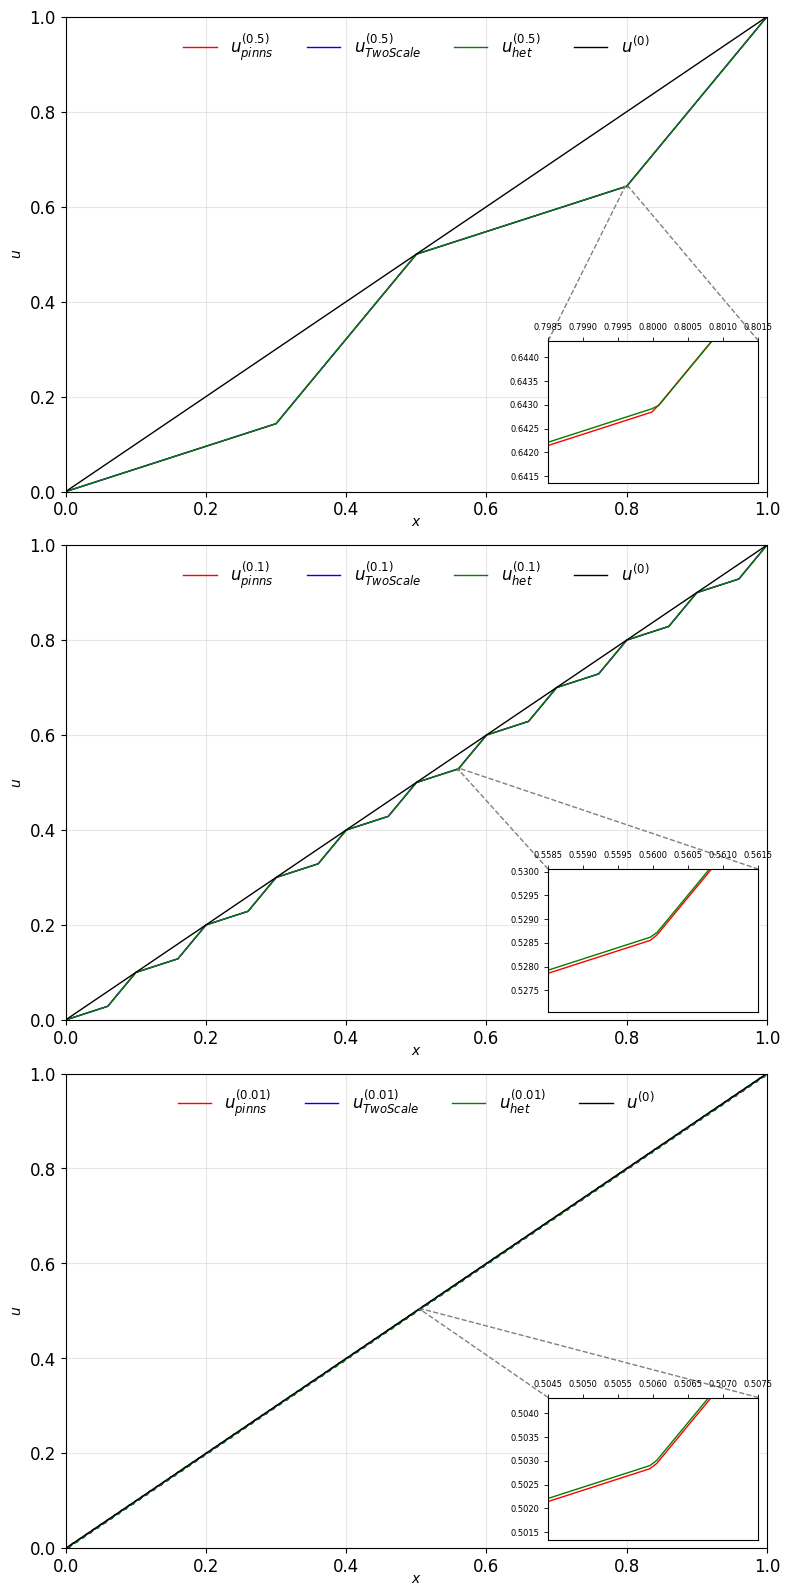

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"

vf = '0.6'
epsilons       = [0.5, 0.1, 0.01]
starting_point = [0.5, 0.5, 0.5]
x_fd = np.linspace(0, 1, 10000)
u_homog = x_fd

fig, axes = plt.subplots(3, 1, figsize=(8, 16))
for i, epsilon in enumerate(epsilons):
    ax = axes[i]

    ax.plot(x_fd, u_pinns[epsilon][vf],    'r', linewidth=1, label=f'$u^{{({epsilon})}}_{{pinns}}$')
    ax.plot(x_fd, u_twoscale[epsilon][vf], 'b', linewidth=1, label=f'$u^{{({epsilon})}}_{{TwoScale}}$')
    ax.plot(x_fd, u_heter[epsilon][vf],    'g', linewidth=1, label=f'$u^{{({epsilon})}}_{{het}}$')
    ax.plot(x_fd, u_homog,                 'k', linewidth=1, label=f'$u^{{(0)}}$')

    ax.set_xlabel(f'$x$')
    ax.set_ylabel(f'$u$')
    ax.xaxis.set_label_coords(0.5, -0.05)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper center', ncol=4, frameon=False)

    #ZOOM
    centerx = starting_point[i] + float(vf) * epsilon
    idx = np.argmin(np.abs(x_fd - centerx))
    centery = u_pinns[epsilon][vf][idx]

    x1z, x2z = centerx - 0.0015, centerx + 0.0015
    y1z, y2z = centery - 0.0015, centery + 0.0015

    ax_inset = inset_axes(ax, width="30%", height="30%", loc='lower right')
    ax_inset.plot(x_fd, u_pinns[epsilon][vf], 'r', linewidth=1)
    ax_inset.plot(x_fd, u_heter[epsilon][vf], 'g', linewidth=1)

    ax_inset.set_xlim(x1z, x2z)
    ax_inset.set_ylim(y1z, y2z)

    ax_inset.tick_params(axis='both', which='major', labelsize=6, length=3, width=0.6)
    ax_inset.xaxis.set_ticks_position('top')
    ax_inset.xaxis.set_label_position('top')

    mark_inset(ax, ax_inset, loc1=1, loc2=2, fc="none", ec="gray", linestyle="--", linewidth=1.0)


fig.subplots_adjust(hspace=0.25)
outname = os.path.join(save_dir, f'pinns_analy_homog_hetero_for_various_epsilons_{date}.png')
plt.savefig(outname, dpi=300,  bbox_inches='tight')
plt.tight_layout()
plt.show()

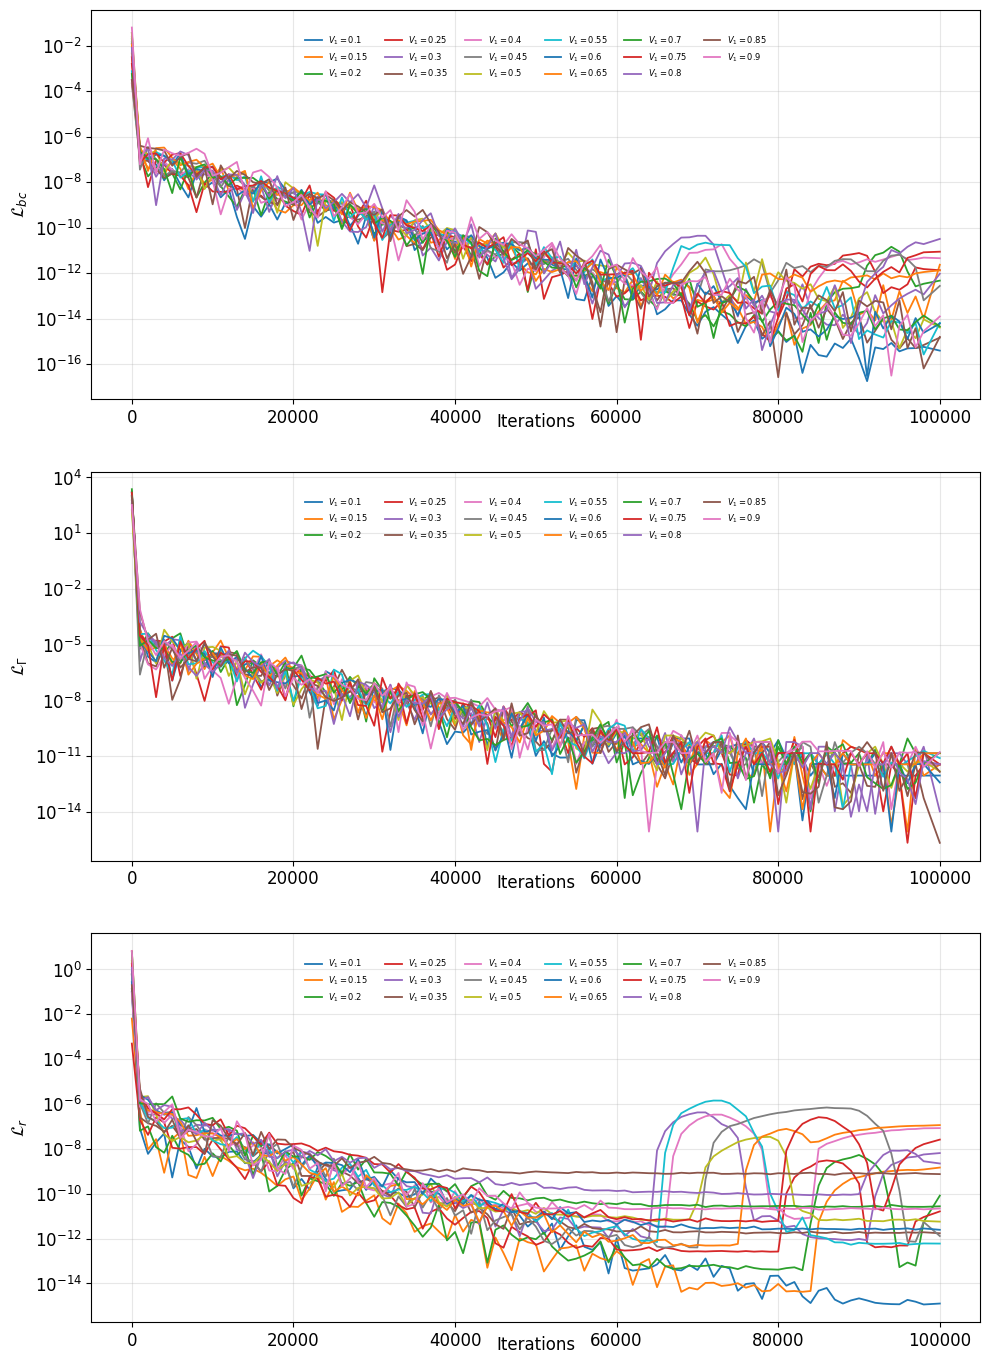

In [28]:
loss_types = ["bc_loss", "interface_loss", "collocation_loss"]
loss_str = [r'$\mathcal{L}_{bc}$', r'$\mathcal{L}_{\Gamma}$', r'$\mathcal{L}_{r}$']

files = [
    'table_losses_total_col_bc_interf2025_11_23_0.1.csv', 'table_losses_total_col_bc_interf2025_11_23_0.2.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.25.csv', 'table_losses_total_col_bc_interf2025_11_23_0.3.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.35.csv', 'table_losses_total_col_bc_interf2025_11_23_0.4.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.45.csv', 'table_losses_total_col_bc_interf2025_11_23_0.5.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.55.csv', 'table_losses_total_col_bc_interf2025_11_23_0.6.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.65.csv', 'table_losses_total_col_bc_interf2025_11_23_0.7.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.75.csv', 'table_losses_total_col_bc_interf2025_11_23_0.8.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.85.csv', 'table_losses_total_col_bc_interf2025_11_23_0.9.csv',
    'table_losses_total_col_bc_interf2025_11_23_0.95.csv']

save_dir  = "/content/drive/My Drive/pinns/Laminado1D/save_soap1"
file_paths = [os.path.join(save_dir, f) for f in files]

vf_str  = ['0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4', '0.45', '0.5',
           '0.55',  '0.6', '0.65', '0.7', '0.75', '0.8', '0.85', '0.9', '0.95']
# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

for ax, loss_name, loss_label in zip(axes, loss_types, loss_str):

    for fname, vf in zip(file_paths, vf_str):
        df = pd.read_csv(fname)
        epochs_rel = list(range(len(df[loss_name]))) #multiplicarlos 1000
        epochs = [x * 1000+1 for x in epochs_rel]
        epochs[-1] = 99999

        ax.plot(
            epochs,
            df[loss_name],
            linewidth=1.3,
            label=rf'$V_1={vf}$'
        )

    ax.set_xlabel("Iterations", labelpad=-10, fontsize=12)
    ax.set_ylabel(loss_label, fontsize=12)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower center',
              ncol=6,
              fontsize=6,
              frameon=False,
              bbox_to_anchor=(0.5, 0.80))

plt.subplots_adjust(hspace=2)
plt.tight_layout()
outname = os.path.join(save_dir, f'training_losses_for_different_vf_{date}.png')
plt.savefig(outname, bbox_inches='tight')
plt.show()

